In [266]:
# Bart Post-COVID Recovery Analysis

#**Question** Which BART stations recovered to pre-pandemic ridership levels, if at all? 

# **Data:** BART monthly origin-destination matrices, 2018–2025, 
# downloaded from bart.gov. Each file contains four tabs (Total Trips, 
# Average Weekday, Average Saturday, Average Sunday) and is structured 
# as a wide matrix with origin stations across columns and destination 
# stations down rows.


# **Notebook 1 of N:** Initial data exploration — understanding what 
# BART actually publishes before doing any analysis.

In [267]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [268]:

data_path = '../Data/raw'
print(os.listdir(data_path))

#rename
for folder_name in os.listdir(data_path):
    if folder_name == '.DS_Store':
        continue
    
    full_path = os.path.join(data_path, folder_name)
    if not os.path.isdir(full_path):
        continue
    
    new_name = folder_name.lower().replace(" ", "_")
    
    if new_name != folder_name:
        old_path = os.path.join(data_path, folder_name)
        new_path = os.path.join(data_path, new_name)
        os.rename(old_path, new_path)
        print(f"renamed: '{folder_name}'  →  '{new_name}'")


['.DS_Store', 'ridership_2018', 'ridership_2020', 'ridership_2021', 'ridership_2019', 'ridership_2023', 'ridership_2024', 'ridership_2025', 'ridership_2022', 'bart_abbs.xls']


In [269]:
#rename
for folder_name in os.listdir(data_path):
    if folder_name == ".DS_Store":
        continue
    
    full_path = os.path.join(data_path, folder_name)
    if not os.path.isdir(full_path):
        continue
    
    new_name = folder_name.lower().replace(" ", "_")
    
    if new_name != folder_name:
        old_path = os.path.join(data_path, folder_name)
        new_path = os.path.join(data_path, new_name)
        os.rename(old_path, new_path)
        print(f"renamed: '{folder_name}'  →  '{new_name}'")

In [270]:
year_2024_p = "../Data/raw/ridership_2024"

for folder_name in sorted(os.listdir(year_2024_p)):
    if folder_name != ".DS_Store":
        print(folder_name)


Ridership_202401.xlsx
Ridership_202402.xlsx
Ridership_202403.xlsx
Ridership_202404.xlsx
Ridership_202405.xlsx
Ridership_202406.xlsx
Ridership_202407.xlsx
Ridership_202408.xlsx
Ridership_202409.xlsx
Ridership_202410.xlsx
Ridership_202411.xlsx
Ridership_202412.xlsx


In [271]:
import pandas as pd

file_path = os.path.join(year_2024_p, "Ridership_202401.xlsx")

xl = pd.ExcelFile(file_path)

print(xl.sheet_names)

['Total Trips', 'Average Weekday', 'Average Saturday', 'Average Sunday']


In [272]:
# Step 3: Open the Average Weekday tab

# For recovery analysis, I'll focus on **Average Weekday** ridership 
# since that's the metric most affected by post-COVID work-from-home 
# patterns. Weekend ridership tells a different story.

# Each tab is structured as a wide origin-destination matrix with 
# origin stations across the columns and destination stations down 
# the rows. Each cell is the average number of trips between those 
# two stations on a typical weekday that month.

In [273]:
weekday_jan_2024 = pd.read_excel(file_path, sheet_name = "Average Weekday")
weekday_jan_2024.head()

,Avg Weekday Trip OD,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 / 01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,...,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday
3,Exit Station Two-Letter Code,RM,EN,EP,NB,BK,AS,MA,19,12,...,SO,MB,WD,OA,WS,PC,AN,ML,BE,NaN
4,RM,12.429,69.667,58.429,33.571,222.714,47.095,75.762,62.190,76.143,...,35.857,11.476,4.190,7.810,13.333,3.952,10.476,5.238,6,2054.857


In [274]:
weekday_jan_2024 = pd.read_excel(file_path, sheet_name = "Average Weekday")
weekday_jan_2024.head()

,Avg Weekday Trip OD,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 / 01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,...,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday
3,Exit Station Two-Letter Code,RM,EN,EP,NB,BK,AS,MA,19,12,...,SO,MB,WD,OA,WS,PC,AN,ML,BE,NaN
4,RM,12.429,69.667,58.429,33.571,222.714,47.095,75.762,62.190,76.143,...,35.857,11.476,4.190,7.810,13.333,3.952,10.476,5.238,6,2054.857


In [275]:
weekday_jan_2024 = pd.read_excel(file_path,skiprows=4)
print(weekday_jan_2024)

   Exit Station Two-Letter Code     RM     EN     EP     NB      BK     AS  \
0                            RM    425   1800   1556    870    5754   1216   
1                            EN   1822    545   1712   1258    9138   1528   
2                            EP   1651   1528    219    884    7677   1167   
3                            NB    884   1056    878    266    2015    648   
4                            BK   6545   9449   7961   2310    1083   3814   
5                            AS   1189   1484   1260    815    3710    297   
6                            MA   2306   2615   1423    987    3854   1073   
7                            19   1700   3598   2307   2055    5049   2138   
8                            12   1993   4282   2526   1897    5024   2019   
9                            LM    521    920    629    498    2225    636   
10                           FV   1358   1586    679    753    3026   1362   
11                           CL   1054    872    247    338    1

In [276]:
!pip install xlrd

In [277]:
stations_p = "../Data/raw/bart_abbs.xls"
stations = pd.read_excel(stations_p, usecols=['Two-Letter Station Code', 'Station Name'])
stations.head()

stations

,Two-Letter Station Code,Station Name
0,RM,Richmond
1,EN,El Cerrito Del Norte
2,EP,El Cerrito Plaza
3,NB,North Berkeley
4,BK,Berkeley
5,AS,Ashby
6,MA,MacArthur
7,19,19th Street Oakland
8,12,12th Street / Oakland City Center
9,LM,Lake Merritt


In [278]:
weekday_jan_2024_long = pd.melt(weekday_jan_2024, id_vars = "Exit Station Two-Letter Code", var_name = "origin", value_name = "trips" )

# Data Above is very long with several "phantom trips"
# Phantom trips can be identified with the same origin and same destination
# Exit Station Two Letter Code needs to be renamed to Origin after further inspection and 

In [279]:

weekday_jan_2024_long[
    (weekday_jan_2024_long["Exit Station Two-Letter Code"] == "EM") &
    (weekday_jan_2024_long["origin"] == "WC")
]

,Exit Station Two-Letter Code,origin,trips
1045,EM,WC,12852


In [280]:
weekday_jan_2024_long = weekday_jan_2024_long.rename(
    columns={"Exit Station Two-Letter Code": "destination"})
weekday_jan_2024_long.head()

,destination,origin,trips
0,RM,RM,425
1,EN,RM,1822
2,EP,RM,1651
3,NB,RM,884
4,BK,RM,6545


In [281]:
weekday_jan_2024_long = weekday_jan_2024_long[["origin", "destination", "trips"]]
weekday_jan_2024_long.head()


,origin,destination,trips
0,RM,RM,425
1,RM,EN,1822
2,RM,EP,1651
3,RM,NB,884
4,RM,BK,6545


###
#Cleaning up Filters like "Grand Total" and "Unamed"


In [282]:
weekday_jan_2024_long["destination"].unique()

array(['RM', 'EN', 'EP', 'NB', 'BK', 'AS', 'MA', '19', '12', 'LM', 'FV',
       'CL', 'SL', 'BF', 'HY', 'SH', 'UC', 'FM', 'CN', 'PH', 'WC', 'LF',
       'OR', 'RR', 'OW', 'EM', 'MT', 'PL', 'CC', '16', '24', 'GP', 'BP',
       'DC', 'CM', 'CV', 'ED', 'NC', 'WP', 'SS', 'SB', 'SO', 'MB', 'WD',
       'OA', 'WS', 'PC', 'AN', 'ML', 'BE', 'Grand Total'], dtype=object)

In [283]:
weekday_jan_2024_clean = weekday_jan_2024_long[
    (weekday_jan_2024_long['origin'] != weekday_jan_2024_long['destination']) &
    (weekday_jan_2024_long['destination'] != 'Grand Total') &
    (weekday_jan_2024_long['origin'] != 'Unnamed: 51')
].copy()

weekday_jan_2024_clean.shape

(2450, 3)

###
# Adding a month column so each row carries its own date. 
# Once we stack data from all 96 files into one DataFrame, this column will let us filter, 
# group, and compare across months — without it, 
# all the rows would look identical regardless of which month they came from.

In [284]:
weekday_jan_2024_clean["month"] = "2024-01"

In [285]:
### Next step: build a reusable function

# After exploring how one BART monthly file is structured, the next step 
# is to wrap the entire cleaning process into a single function. That way, 
# applying the same recipe to all 96 monthly files becomes a one-line call 
# inside a loop.

In [286]:
def find_header_row(file_path, sheet_name):
    raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    for i in range(len(raw)):
        cell = raw.iloc[i, 0]
        if isinstance(cell, str) and 'Exit Station' in cell:
            return i
    return None 
    

In [287]:
def load_and_clean_month(file_path):

    xl = pd.ExcelFile(file_path)
    filename = os.path.basename(file_path)
    
    weekday_sheet = None
    for sheet in xl.sheet_names:
        if "Weekday" in sheet:
            weekday_sheet = sheet
            break

    if "OD" in weekday_sheet:
        skip = 1
    # These 2 files (out of 96) have one fewer header row than their siblings,
    # so the station-code row is at index 3 instead of 4. skiprows=3 fixes them.
    elif filename in ["Ridership_202410.xlsx" , "Ridership_202508.xlsx"]:
        skip = 3
    else:
        skip = 4
           
    ridership_df = pd.read_excel(file_path, sheet_name= weekday_sheet, skiprows = skip)
    ridership_df = pd.melt(ridership_df, id_vars=ridership_df.columns[0], var_name="origin", value_name="trips")
    ridership_df = ridership_df.rename(columns={ridership_df.columns[0]: "destination"})
    ridership_df = ridership_df[["origin", "destination", "trips"]]
    ridership_df = ridership_df[
            (ridership_df["origin"] != ridership_df["destination"]) &
        (ridership_df["destination"] != "Grand Total") &
        (ridership_df["origin"] != "Unnamed: 51")].copy()
    ridership_df["month"] = f"{filename[10:14]}-{filename[14:16]}"
    return ridership_df


In [288]:
test = load_and_clean_month("../Data/raw/ridership_2024/Ridership_202401.xlsx")
test.shape

(2450, 4)

#sanity check

In [289]:
test_march = load_and_clean_month("../Data/raw/ridership_2024/Ridership_202403.xlsx")
test_march.shape
test_march.head()

,origin,destination,trips,month
1,RM,EN,70.476,2024-03
2,RM,EP,64.667,2024-03
3,RM,NB,35.667,2024-03
4,RM,BK,283.333,2024-03
5,RM,AS,44.667,2024-03


### Next Step: Creating a Loop to go through the files BART has Published

In [290]:
all_months = []

for year_folder in sorted(os.listdir(data_path)):
    year_path = os.path.join(data_path, year_folder)
    if not os.path.isdir(year_path):
        continue
    
    for filename in sorted(os.listdir(year_path)):
        if filename == ".DS_Store":
            continue

        full_path = os.path.join(year_path, filename)
        print(full_path)
        cleaned = load_and_clean_month(full_path)
        all_months.append(cleaned)

all_data = pd.concat(all_months, ignore_index=True)
all_data.shape        

    

../Data/raw/ridership_2018/Ridership_201801.xlsx
../Data/raw/ridership_2018/Ridership_201802.xlsx
../Data/raw/ridership_2018/Ridership_201803.xlsx
../Data/raw/ridership_2018/Ridership_201804.xlsx
../Data/raw/ridership_2018/Ridership_201805.xlsx
../Data/raw/ridership_2018/Ridership_201806.xlsx
../Data/raw/ridership_2018/Ridership_201807.xlsx
../Data/raw/ridership_2018/Ridership_201808.xlsx
../Data/raw/ridership_2018/Ridership_201809.xlsx
../Data/raw/ridership_2018/Ridership_201810.xlsx
../Data/raw/ridership_2018/Ridership_201811.xlsx
../Data/raw/ridership_2018/Ridership_201812.xlsx
../Data/raw/ridership_2019/Ridership_201901.xlsx
../Data/raw/ridership_2019/Ridership_201902.xlsx
../Data/raw/ridership_2019/Ridership_201903.xlsx
../Data/raw/ridership_2019/Ridership_201904.xlsx
../Data/raw/ridership_2019/Ridership_201905.xlsx
../Data/raw/ridership_2019/Ridership_201906.xlsx
../Data/raw/ridership_2019/Ridership_201907.xlsx
../Data/raw/ridership_2019/Ridership_201908.xlsx
../Data/raw/ridershi

(240920, 4)

In [291]:
all_data.shape

(240920, 4)

In [292]:
all_data['month'].value_counts().sort_index()

month
2018-01    2163
2018-02    2163
2018-03    2163
2018-04    2163
2018-05    2551
           ... 
2025-08    2450
2025-09    2450
2025-10    2450
2025-11    2450
2025-12    2450
Name: count, Length: 96, dtype: int64

In [293]:
# Are months continuous, no gaps?
print(all_data['month'].nunique())   # how many distinct months — should be 96 (or however many you actually downloaded)

96


In [294]:
all_data[
    (all_data['origin'] == 'EM') &
    (all_data['destination'] == 'WC')
].sort_values('month').head(20)

,origin,destination,trips,month
1170,EM,WC,1429.238,2018-01
3333,EM,WC,1388.842,2018-02
5496,EM,WC,1376.318,2018-03
7659,EM,WC,1377.095,2018-04
9922,EM,WC,1391.227,2018-05
12473,EM,WC,1452.476,2018-06
15024,EM,WC,1434.238,2018-07
17575,EM,WC,1425.957,2018-08
20126,EM,WC,1431.474,2018-09
22677,EM,WC,1405.727,2018-10


In [295]:
all_data[(all_data["origin"] == "EM") & (all_data["destination"] == "WC") & (all_data["month"] == "2024-01")]
all_data[(all_data["origin"] == "WC") & (all_data["destination"] == "EM") & (all_data["month"] == "024-01")]

,origin,destination,trips,month


In [296]:
result = all_data.groupby('origin')['trips'].sum()
result

origin
12        993686.160
16       1000962.493
19        951226.044
24        981856.474
12        127237.807
16        136166.064
19        114798.746
24        134777.325
AN        280177.094
AS        434081.639
BE         96873.040
BF        505675.585
BK        975304.104
BP        966405.839
CC       2096638.673
CL        546268.322
CM        362042.891
CN        512741.676
CV        245340.382
DC        846860.131
ED        665773.026
EM       3291521.680
EN        720694.931
EP        414040.761
Exits   31026111.936
FM        475760.401
FV        760192.681
GP        665423.344
HY        436272.580
LF        295488.920
LM        611542.189
MA        768652.247
MB        490338.141
ML         82514.653
MT       3219369.871
NB        360403.581
NC        172942.478
OA        130229.131
OR        248165.302
OW        713236.025
PC        105453.612
PH        597108.521
PL       2576963.209
RM        444816.267
RR        456784.787
SB        306371.286
SH        287934.735
SL    

In [297]:
all_data['origin'].unique()

array(['RM', 'EN', 'EP', 'NB', 'BK', 'AS', 'MA', 19, 12, 'LM', 'FV', 'CL',
       'SL', 'BF', 'HY', 'SH', 'UC', 'FM', 'CN', 'PH', 'WC', 'LF', 'OR',
       'RR', 'OW', 'EM', 'MT', 'PL', 'CC', 16, 24, 'GP', 'BP', 'DC', 'CM',
       'CV', 'ED', 'NC', 'WP', 'SS', 'SB', 'SO', 'MB', 'WD', 'OA', 'WS',
       'Exits', 'ML', 'BE', 'PC', 'AN', '19', '12', '16', '24'],
      dtype=object)

In [298]:
all_data['origin'].value_counts()

origin
RM       4760
RR       4760
EM       4760
MT       4760
EN       4760
CC       4760
GP       4760
BP       4760
DC       4760
CM       4760
CV       4760
ED       4760
NC       4760
WP       4760
SS       4760
SB       4760
SO       4760
MB       4760
WD       4760
OA       4760
WS       4760
OW       4760
PL       4760
OR       4760
BF       4760
EP       4760
NB       4760
BK       4760
AS       4760
MA       4760
LF       4760
LM       4760
FV       4760
CL       4760
SL       4760
HY       4760
SH       4760
UC       4760
FM       4760
CN       4760
PH       4760
WC       4760
ML       4576
PC       4576
BE       4576
AN       4576
Exits    3656
12       3584
19       3584
24       3584
16       3584
19       1176
12       1176
16       1176
24       1176
Name: count, dtype: int64

In [299]:
test_2018 = pd.read_excel('../Data/raw/ridership_2018/Ridership_201801.xlsx', sheet_name='Weekday OD', skiprows=1)
test_2018.columns.tolist()

['Unnamed: 0',
 'RM',
 'EN',
 'EP',
 'NB',
 'BK',
 'AS',
 'MA',
 19,
 12,
 'LM',
 'FV',
 'CL',
 'SL',
 'BF',
 'HY',
 'SH',
 'UC',
 'FM',
 'CN',
 'PH',
 'WC',
 'LF',
 'OR',
 'RR',
 'OW',
 'EM',
 'MT',
 'PL',
 'CC',
 16,
 24,
 'GP',
 'BP',
 'DC',
 'CM',
 'CV',
 'ED',
 'NC',
 'WP',
 'SS',
 'SB',
 'SO',
 'MB',
 'WD',
 'OA',
 'WS',
 'Exits']

In [300]:
# Find rows where origin is a decimal-looking value
weird = all_data[all_data['origin'] == 23.818181818181813]
weird['month'].unique()


array([], dtype=object)

In [301]:
# Check the data type of each origin value
all_data['origin'].apply(type).value_counts()

origin
<class 'str'>    226584
<class 'int'>     14336
Name: count, dtype: int64

In [302]:
bad_rows = all_data[all_data['origin'].apply(type) == float]
bad_rows['month'].unique()

array([], dtype=object)

In [303]:
###
# While running sanity checks on `all_data['origin'].unique()`, I 
# discovered 4,606 rows where the origin column contained float values 
# (decimals like 23.81, 75.04) instead of station codes. Investigating 
# with `.apply(type)` showed that 4,606 origin values are floats and 
# 14,630 are ints — the rest (221,782) are correctly strings.

# Filtering by data type, I traced the float-typed origins to two 
# specific months: **October 2024 and August 2025**. All other 94 
# months are clean.

# It could be that BART had a different sheet structure than their sibling files in the same year.
#The function maybe reading the wrong row as headers, causing decimals to be labled as "origins"

### Next steps
# 1. Open the 2024-10 file and check sheet names + structure
# 2. Compare to a working file from the same year (2024-01)
# 3. Update the function to handle whatever variation exists
# 4. Re-run the loop with the fix
# 5. Verify origin column is now clean

In [304]:
def trips_by_origin(year):
    filter = all_data[all_data["month"].str.startswith(str(year))]
    result = filter.groupby("origin")["trips"].sum()
    return result.sort_values(ascending=False)

In [305]:
all_data['origin'] = all_data['origin'].astype(str)
all_data['destination'] = all_data['destination'].astype(str)

In [306]:
all_data['origin'].apply(type).value_counts()
all_data['origin'].nunique()

51

In [307]:
all_data = all_data[all_data['origin'] != 'Exits']

In [308]:
all_data['origin'].unique()

array(['RM', 'EN', 'EP', 'NB', 'BK', 'AS', 'MA', '19', '12', 'LM', 'FV',
       'CL', 'SL', 'BF', 'HY', 'SH', 'UC', 'FM', 'CN', 'PH', 'WC', 'LF',
       'OR', 'RR', 'OW', 'EM', 'MT', 'PL', 'CC', '16', '24', 'GP', 'BP',
       'DC', 'CM', 'CV', 'ED', 'NC', 'WP', 'SS', 'SB', 'SO', 'MB', 'WD',
       'OA', 'WS', 'ML', 'BE', 'PC', 'AN'], dtype=object)

In [309]:
pd.options.display.float_format = '{:,.0f}'.format
print("2024:")
print(trips_by_origin(2024).head(10))
print("\n2019:")
print(trips_by_origin(2019).head(10))


2024:
origin
EM   175,590
MT   148,726
PL   139,138
CC   113,151
16    66,143
24    65,492
BK    62,382
12    60,409
DC    54,524
19    54,440
Name: trips, dtype: float64

2019:
origin
MT   1,021,992
EM     986,654
PL     700,438
CC     591,323
12     328,538
19     320,180
16     311,026
24     298,793
BP     269,472
BK     256,759
Name: trips, dtype: float64


In [310]:
aggregated_df = all_data.groupby("month")["trips"].sum().reset_index()
aggregated_df

,month,trips
0,2018-01,"789,005"
1,2018-02,"826,278"
2,2018-03,"816,011"
3,2018-04,"824,487"
4,2018-05,"831,998"
...,...,...
91,2025-08,"184,898"
92,2025-09,"192,977"
93,2025-10,"196,555"
94,2025-11,"184,397"


<Axes: title={'center': 'BART System-Wide Average Weekday Ridership (2018-2025)'}, xlabel='month'>

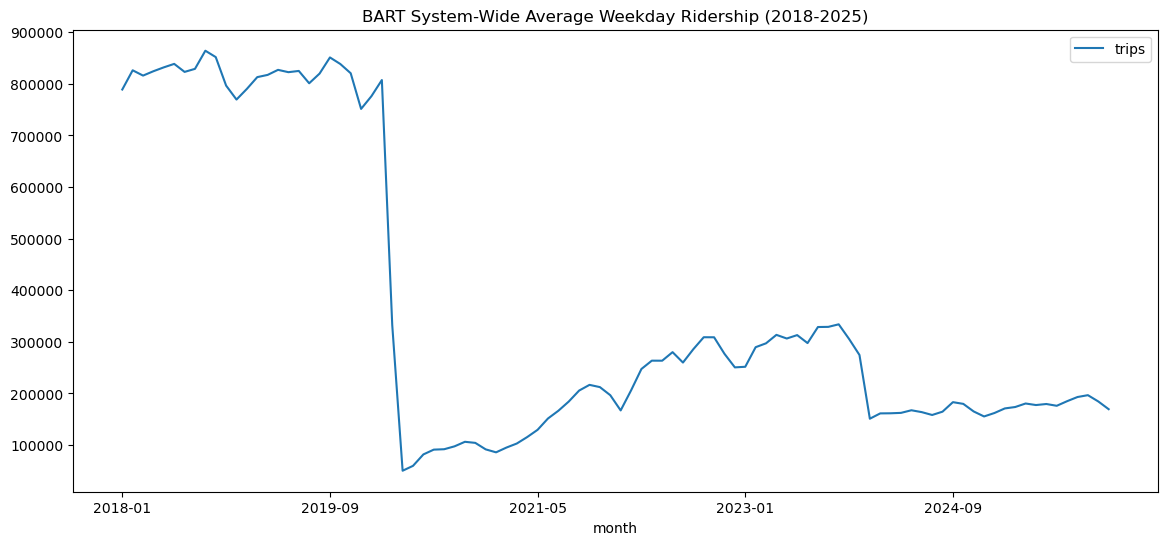

In [311]:
aggregated_df.plot(x = "month", y = "trips", figsize = (14,6), title = "BART System-Wide Average Weekday Ridership (2018-2025)")

In [312]:
### noticed a drop from 2023 to 2024.

In [313]:
# ### Recovery Analysis:

# **Baseline definition:** Average of Jan 2018 – Feb 2020 (the full pre-COVID window).
# Rationale: Using a two-year average reduces noise from any single month and 
# captures BART's typical pre-pandemic ridership more reliably than Feb 2020 alone.

# #Disclosure, there is a sudden drop from 2023 to 2024, however it was due to a methodology 
# #change by BART

In [314]:
pre_covid = all_data[all_data["month"].between('2018-01', '2020-02')]
baseline_df = pre_covid.groupby('origin')['trips'].sum()
baseline_df = baseline_df / 26
baseline_df.sort_values(ascending=False).head(10)

origin
MT   85,524
EM   82,030
PL   58,541
CC   48,992
12   27,293
19   26,753
16   25,362
24   24,852
BP   22,622
BK   21,570
Name: trips, dtype: float64

In [315]:
monthy_origin = all_data.groupby(["origin", "month"])["trips"].sum().reset_index()

In [316]:
monthly_origin = monthly_origin[["origin", "trips", "month"]]
monthly_origin.head()

,origin,trips,month
0,12,"26,187",2018-01
1,12,"27,316",2018-02
2,12,"26,732",2018-03
3,12,"26,637",2018-04
4,12,"27,670",2018-05


In [317]:
print(monthly_origin.shape)


(4784, 3)


In [318]:
recovery_df = monthly_origin.merge(baseline_df, on='origin', suffixes=('_current', '_baseline'))
recovery_df.head()

,origin,trips_current,month,trips_baseline
0,12,"26,187",2018-01,"27,293"
1,12,"27,316",2018-02,"27,293"
2,12,"26,732",2018-03,"27,293"
3,12,"26,637",2018-04,"27,293"
4,12,"27,670",2018-05,"27,293"


In [319]:
pd.options.display.float_format = '{:.3f}'.format
recovery_df['recovery_index'] = recovery_df['trips_current'] / recovery_df['trips_baseline']
recovery_df = recovery_df[recovery_df['trips_baseline'] > 0]
recovery_df.head(100)

,origin,trips_current,month,trips_baseline,recovery_index
0,12,26186.524,2018-01,27293.063,0.959
1,12,27316.263,2018-02,27293.063,1.001
2,12,26732.273,2018-03,27293.063,0.979
3,12,26637.429,2018-04,27293.063,0.976
4,12,27669.682,2018-05,27293.063,1.014
...,...,...,...,...,...
95,12,5161.000,2025-12,27293.063,0.189
96,16,23914.571,2018-01,25361.947,0.943
97,16,24957.368,2018-02,25361.947,0.984
98,16,24425.091,2018-03,25361.947,0.963


In [320]:
### Recovery Index

# The recovery index measures each station's monthly ridership as a fraction 
# of its pre-COVID baseline (Jan 2018 – Feb 2020 average). A value of 1.0 
# means the station is back to baseline. Values above 1.0 mean it exceeded 
# baseline; below 1.0 means it hasn't fully recovered.

# Pre-COVID months (2018 – Feb 2020) naturally cluster near 1.0 with small 
# seasonal variation — January tends to be slightly below baseline, summer 
# months slightly above. The meaningful story starts in March 2020.


In [321]:
sys_wide_df = recovery_df.groupby("month")["recovery_index"].mean().reset_index()
sys_wide_df

,month,recovery_index
0,2018-01,0.980
1,2018-02,1.028
2,2018-03,1.018
3,2018-04,1.030
4,2018-05,1.003
...,...,...
91,2025-08,0.236
92,2025-09,0.246
93,2025-10,0.249
94,2025-11,0.233


<Axes: title={'center': 'BART System-Wide Recovery Index (2018-2025'}, xlabel='month'>

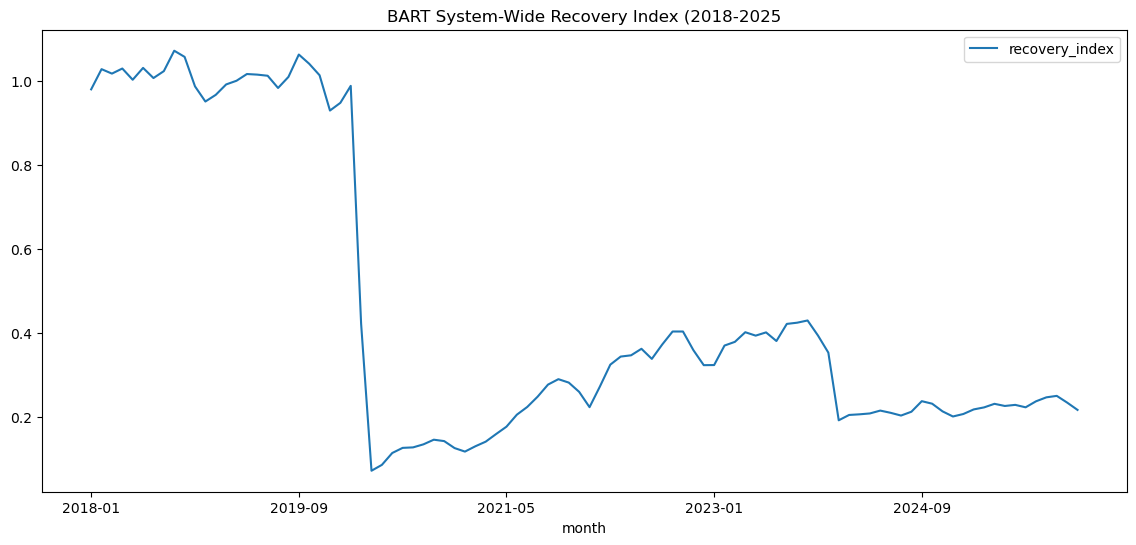

In [322]:
sys_wide_df.plot(x = "month", y = "recovery_index", figsize = (14,6), title = "BART System-Wide Recovery Index (2018-2025")

In [323]:
### y-axis changed from trips to recovery index

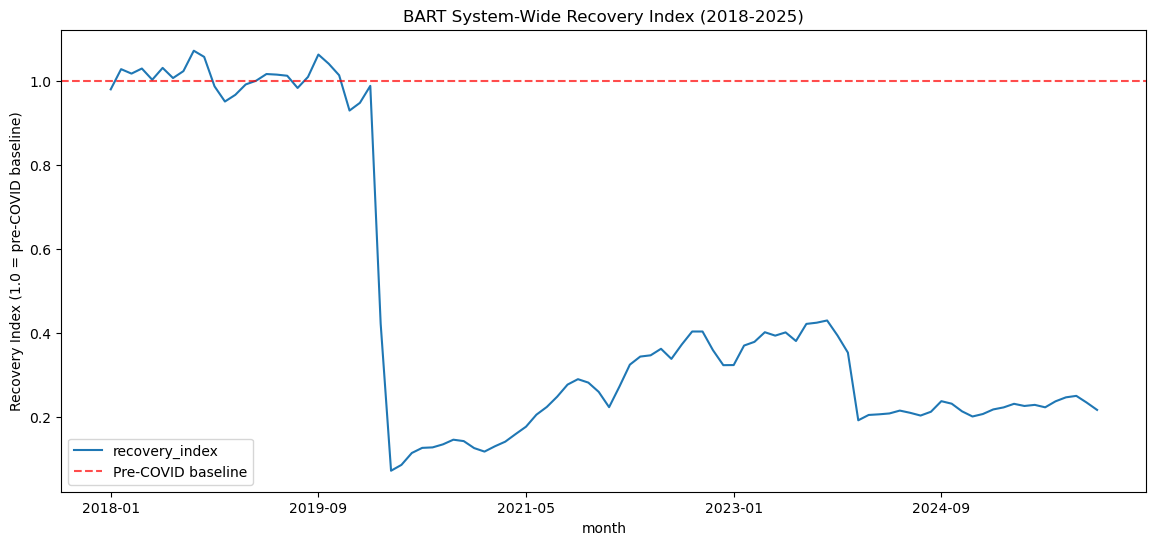

In [324]:
ax = sys_wide_df.plot(x='month', y='recovery_index', figsize=(14,6),
                      title='BART System-Wide Recovery Index (2018-2025)')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Pre-COVID baseline')
ax.set_ylabel('Recovery Index (1.0 = pre-COVID baseline)')
ax.legend()

In [325]:
### Between 2023 and early 2024, there was a methodology break in how BART measures trips

In [326]:
recovery_filtered = recovery_df[recovery_df["month"] == "2023-12"].sort_values(by = "recovery_index", ascending = False)
recovery_filtered

,origin,trips_current,month,trips_baseline,recovery_index
451,AN,2962.905,2023-12,4728.312,0.627
4183,SO,6752.429,2023-12,12552.834,0.538
3703,RM,4073.905,2023-12,8754.838,0.465
3415,PC,918.190,2023-12,1977.605,0.464
4087,SL,5341.524,2023-12,12230.827,0.437
3131,OA,1135.524,2023-12,2709.400,0.419
2079,FV,6414.238,2023-12,15521.844,0.413
735,BF,4263.476,2023-12,10818.154,0.394
2367,LF,2694.571,2023-12,6852.727,0.393
3607,PL,23015.429,2023-12,58541.082,0.393


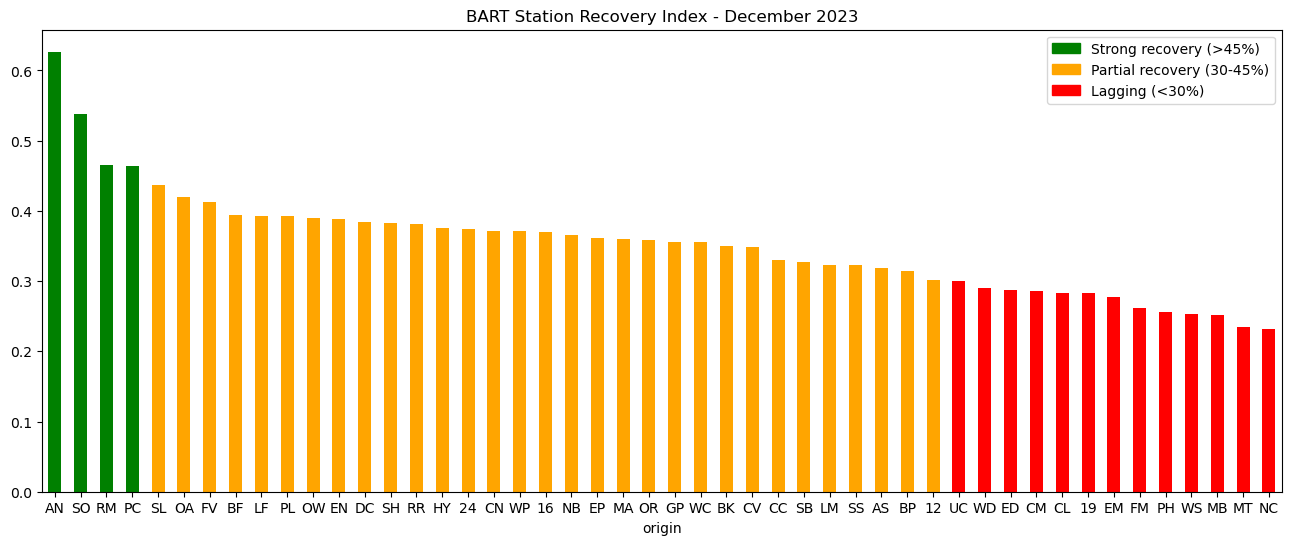

In [327]:
import matplotlib.patches as mpatches

colors = ['green' if x > 0.45 else 'orange' if x > 0.30 else 'red' 
          for x in recovery_filtered["recovery_index"]]

recovery_filtered.plot(x = "origin", y = "recovery_index", 
                       kind = "bar", figsize = (16,6), 
                       title = "BART Station Recovery Index - December 2023", 
                       rot = 0, 
                       color = colors, 
                       legend = True
)

green_patch = mpatches.Patch(color='green', label='Strong recovery (>45%)')
orange_patch = mpatches.Patch(color='orange', label='Partial recovery (30-45%)')
red_patch = mpatches.Patch(color='red', label='Lagging (<30%)')

plt.legend(handles=[green_patch, orange_patch, red_patch])
plt.show()

